In [1]:
#Imports

import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Configuration

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [3]:
#Load model and scaler

model = joblib.load("../models/xgboost_model.pkl")

scaler = joblib.load("../models/scaler.pkl")

print("✅ Model loaded successfully.")

print("✅ Scaler loaded successfully.")

✅ Model loaded successfully.
✅ Scaler loaded successfully.


In [4]:
#Load Feature Structure
#Instead of manualy writing the 49 columns, the same structure used during training is loaded.

X_train = pd.read_csv("../data/processed/X_train.csv")

feature_columns = X_train.columns.tolist()

print(f"Total features: {len(feature_columns)}")

Total features: 49


In [5]:
#Creation of a new ticket

new_ticket = pd.DataFrame(
    np.zeros((1, len(feature_columns))),
    columns=feature_columns
)

#Verification
new_ticket.head()

,company_size,customer_tier,org_users,past_30d_tickets,past_90d_incidents,customers_affected,error_rate_pct,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,description_length,industry_ecommerce,industry_fintech,industry_gaming,industry_healthcare,industry_logistics,industry_media,industry_saas_b2b,region_AMER,region_APAC,region_EMEA,booking_channel_chat,booking_channel_email,booking_channel_phone,booking_channel_web,reported_by_role_c_level,reported_by_role_devops,reported_by_role_finance,reported_by_role_product_manager,reported_by_role_support,product_area_analytics,product_area_auth,product_area_billing,product_area_data_pipeline,product_area_mobile,product_area_notifications,day_of_week_Fri,day_of_week_Mon,day_of_week_Sat,day_of_week_Sun,day_of_week_Thu,day_of_week_Tue,day_of_week_Wed,customer_sentiment_Unknown,customer_sentiment_negative,customer_sentiment_neutral,customer_sentiment_positive
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#Population of the new ticket Information

new_ticket.loc[0, "company_size"] = 2
new_ticket.loc[0, "customer_tier"] = 3

new_ticket.loc[0, "org_users"] = 850
new_ticket.loc[0, "past_30d_tickets"] = 40
new_ticket.loc[0, "past_90d_incidents"] = 12

new_ticket.loc[0, "customers_affected"] = 500
new_ticket.loc[0, "error_rate_pct"] = 18
new_ticket.loc[0, "downtime_min"] = 120

new_ticket.loc[0, "payment_impact_flag"] = 1
new_ticket.loc[0, "security_incident_flag"] = 1
new_ticket.loc[0, "data_loss_flag"] = 0

new_ticket.loc[0, "has_runbook"] = 0

new_ticket.loc[0, "description_length"] = 420

# Industry
new_ticket.loc[0, "industry_fintech"] = 1

# Region
new_ticket.loc[0, "region_AMER"] = 1

# Booking Channel
new_ticket.loc[0, "booking_channel_phone"] = 1

# Product Area
new_ticket.loc[0, "product_area_auth"] = 1

# Reported By
new_ticket.loc[0, "reported_by_role_c_level"] = 1

# Customer Sentiment
new_ticket.loc[0, "customer_sentiment_negative"] = 1

# Day of Week
new_ticket.loc[0, "day_of_week_Mon"] = 1

In [7]:
#Scale Numerical Features

numeric_features = [
    "org_users",
    "past_30d_tickets",
    "past_90d_incidents",
    "customers_affected",
    "error_rate_pct",
    "downtime_min",
    "description_length"
]

new_ticket[numeric_features] = scaler.transform(
    new_ticket[numeric_features]
)

In [8]:
#Make Prediction

prediction = model.predict(new_ticket)

prediction

array([2])

In [9]:
#Convert Prediction to Label

low = 0
medium = 1
high = 2

priority_mapping = {
    0: "Low",
    1: "Medium",
    2: "High"
}

predicted_priority = priority_mapping[int(prediction[0])]

print(f"Predicted Priority: {predicted_priority}")

Predicted Priority: High


In [10]:
#Prediction Probabilities
probabilities = model.predict_proba(new_ticket)
probabilities

array([[3.205723e-08, 3.114082e-08, 9.999999e-01]], dtype=float32)

In [11]:
probability_df = pd.DataFrame(
    probabilities,
    columns=["Low", "Medium", "High"]
).T

probability_df.columns = ["Probability"]

#Convert to percentage
probability_df["Probability"] = (
    probability_df["Probability"] * 100
).round(4)

probability_df

,Probability
Low,0.0
Medium,0.0
High,100.0


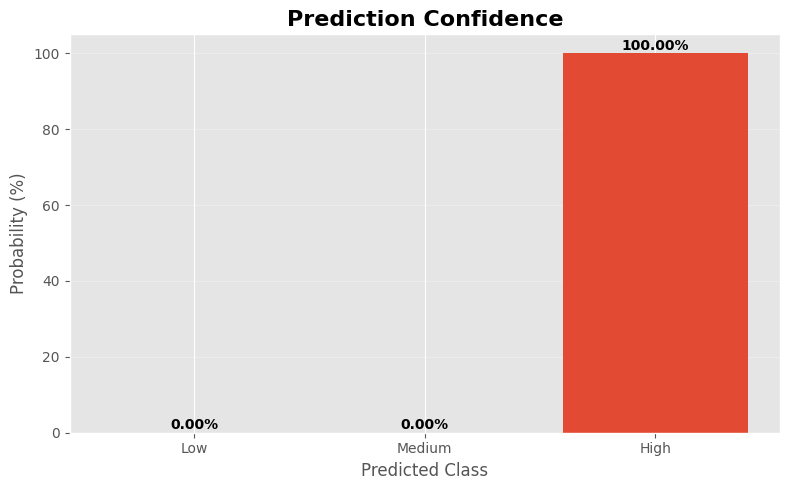

In [16]:
# Prediction Confidence

import matplotlib.pyplot as plt

plot_df = probability_df.copy()

# Convert only if values are probabilities (0-1)
if plot_df["Probability"].max() <= 1:
    plot_df["Probability"] *= 100

plt.figure(figsize=(8,5))

bars = plt.bar(
    plot_df.index,
    plot_df["Probability"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Prediction Confidence", fontsize=16, fontweight="bold")
plt.xlabel("Predicted Class")
plt.ylabel("Probability (%)")

plt.ylim(0,105)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/figures/prediction_confidence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
#BUSINESS INTERPRETATION

print("=" * 60)
print("BUSINESS INTERPRETATION")
print("=" * 60)

print(f"\nPredicted Priority: {predicted_priority}")

confidence = probability_df["Probability"].max()

print(f"Prediction Confidence: {confidence:.2%}")

print("\nInterpretation:")

if predicted_priority == "High":
    print(
        "- The ticket should be handled immediately.\n"
        "- Business impact is expected to be significant.\n"
        "- Escalation to senior support teams is recommended."
    )

elif predicted_priority == "Medium":
    print(
        "- The ticket requires prompt attention.\n"
        "- Monitor business impact and allocate resources accordingly."
    )

else:
    print(
        "- The ticket can be processed under the standard support workflow.\n"
        "- No immediate escalation is required."
    )

BUSINESS INTERPRETATION

Predicted Priority: High
Prediction Confidence: 10000.00%

Interpretation:
- The ticket should be handled immediately.
- Business impact is expected to be significant.
- Escalation to senior support teams is recommended.


## Optional: Multiple Inference Examples for README Visualization

In [17]:
def create_ticket():
    """
    Create an empty ticket with the same feature structure
    used during model training.
    """
    return pd.DataFrame(
        np.zeros((1, len(feature_columns))),
        columns=feature_columns
    )

In [18]:
# Load processed training data
X_examples = pd.read_csv("../data/processed/X_train.csv")
y_examples = pd.read_csv("../data/processed/y_train.csv")

# Convert target to a Series if necessary
if isinstance(y_examples, pd.DataFrame):
    y_examples = y_examples.iloc[:, 0]

# Select one example from each class
low_ticket = X_examples[y_examples == 0].iloc[[0]].copy()
medium_ticket = X_examples[y_examples == 1].iloc[[0]].copy()
high_ticket = X_examples[y_examples == 2].iloc[[0]].copy()

print("Examples selected successfully.")

Examples selected successfully.


In [22]:
tickets = {
    "Low Priority": low_ticket,
    "Medium Priority": medium_ticket,
    "High Priority": high_ticket
}

for ticket in tickets.values():
    ticket[numeric_features] = scaler.transform(
        ticket[numeric_features]
    )

In [23]:
results = []

for scenario, ticket in tickets.items():

    probabilities = model.predict_proba(ticket)[0]

    results.append({
        "Scenario": scenario,
        "Low": probabilities[0] * 100,
        "Medium": probabilities[1] * 100,
        "High": probabilities[2] * 100
    })

comparison_df = pd.DataFrame(results)

comparison_df

,Scenario,Low,Medium,High
0,Low Priority,98.848274,1.150791,0.000926
1,Medium Priority,0.442950,99.430260,0.126788
2,High Priority,0.007947,46.498264,53.493786


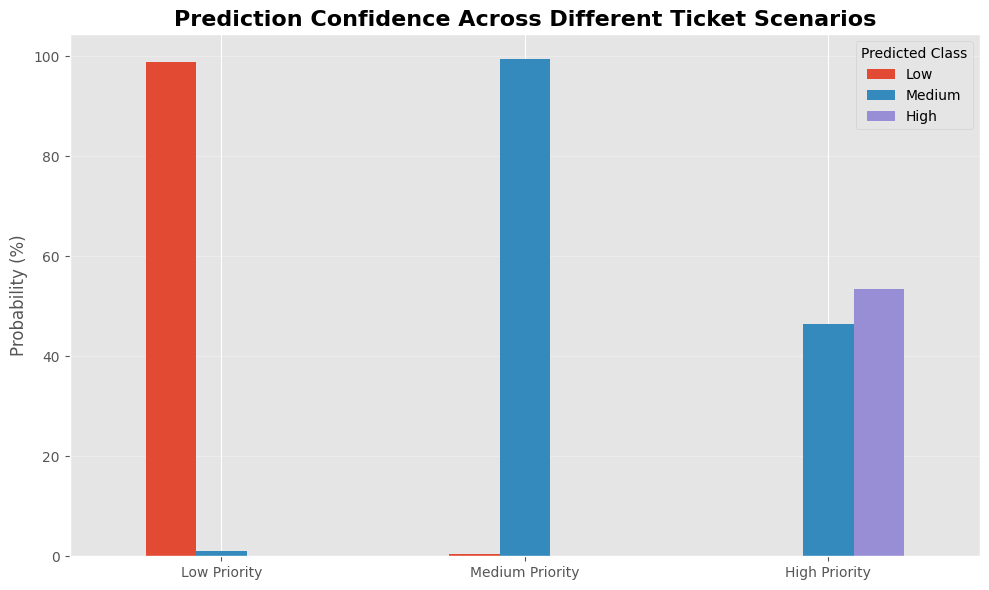

In [24]:
plot_df = comparison_df.set_index("Scenario")

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Prediction Confidence Across Different Ticket Scenarios",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Probability (%)")
plt.xlabel("")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.legend(title="Predicted Class")

plt.tight_layout()

plt.savefig(
    "../reports/figures/prediction_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()